In [1]:
from neuron import h
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!nrnivmodl

/usr/bin/xcrun
/Users/ychsu/Downloads/stableRelease_v3_090915
Mod files: "./calH.mod" "./dists.mod" "./eff.mod" "./exc.mod" "./id.mod" "./inh.mod" "./kad.mod" "./kap.mod" "./kdr.mod" "./na3.mod" "./nmdaSyn.mod" "./sl.mod" "./syns.mod" "./vmax.mod" "./vmin.mod"

 -> Compiling mod_func.cpp
 => LINKING shared library ./libnrnmech.dylib
Successfully created x86_64/special


In [3]:
h.load_file("nrngui.hoc")

1.0

In [4]:
h("cellId = 1") #choose to cell to simulate; 1 or 2.
h.load_file("loadMorph.hoc")
h.load_file("resetNSeg.hoc")

1.0

In [5]:
h.load_file("proofreadMorph.hoc") #PROOFREAD MORPHOLOGY.
h.load_file("idMorph.hoc")
h.load_file("processMorph.hoc")

The number of effective branches is 120 
	1 


1.0

In [6]:
h.load_file("morphSummary.hoc")

tuftTermSa=2091.3942 
tufIntSa=880.34153 
oblTermSa=3813.0366 
oblIntSa=489.70324 
truckSa=1588.2207 
basPrimSa=203.36696 
basIntSa=906.95605 
basTermSa=2946.9947 
tuftTermL=1255.9764 
tuftIntL=298.56213 
oblTermL=1954.9848 
oblIntL=206.64296 
trunkL=275.91333 
basPrimL=39.149127 
basIntL=395.55933 
basTermL=1510.9204 


1.0

In [7]:
h.load_file("addChannels.hoc")

1.0

In [8]:
h.load_file("initializationAndRun.hoc")
h.load_file("displayPanels.hoc")
	
doMovie=0
if doMovie:
	h.load_file("step.hoc")

	1 
	0 


In [9]:
h.load_file("addVgatInhibition.hoc")
h.load_file("synHelperScripts.hoc") #scripts retrieving synapse information
h.load_file("flagVgatInhibition.hoc")
h.load_file("inhibitionBiophysics.hoc") # assign vgat properties
h.load_file("activateInhibition.hoc") # script toggling active inhibition

#h.load_file("checkConsistency.hoc") // deprecated; replaced by modelExpCheck below

h("seedGenotypes()") #add in inhibition
h.load_file("viewInhibition.hoc")

The total number of VGAT+ synapses in tuft is: 280 
The total number of VGAT+ synapses in obliques is: 114 
The total number of VGAT+ synapses in main apical is: 36 
The total number of VGAT+ synapses in soma is: 0 
The total number of VGAT+ synapses in basals is: 166 
The total number of VGAT+ synapses is: 596 
The total number of SST synapses in tuft is 164 
The total number of NPY synapses in obliques is 68 
The total number of NPY synapses in trunk is 30 
The total number of NPY synapses at soma is 0 
The total number of NPY synapses in basal is 86 
The total number of PV synapses in obliques is 15 
The total number of PV synapses at soma is 20 
The total number of PV synapses in basal is 16 
	1 
	1 
	1 
	1 
	1 
	1 


1.0

In [10]:
h.load_file("addExcitation.hoc")
h.load_file("activateExcitation.hoc") #script toggling active excitation
h.load_file("viewExcitation.hoc")

Number of excitatory connections is: 9510 
	1 


1.0

In [11]:
h("""
strdef genotypeToUse,domainToSurvey
{

	doCheck=0
	if(doCheck){
		genotypeToUse = "vgat" //  TYPE OF SYNAPSE, ONE OF"exc","vgat","sst","npy"
		domainToSurvey = "tuft" // DOMAIN TO CONSIDER, ONE OF "basal","prim","obl","tuft"
		partitionsToUse = 3 // NUMBER OF PARTITIONS.  AT DATA WAS EITHER = 1 OR = 3.
		
		load_file("modelExpCheck.hoc")
		modelExpCheck(genotypeToUse,domainToSurvey,partitionsToUse)
	}
}
""")

1

In [19]:
mech_selected = []

sec_mechs = [set(sec.psection()["density_mechs"].keys()) for sec in h.allsec()]
mechs = sec_mechs[0].union(*sec_mechs[1:])

for mech in mechs:
    if mech in ["pas"]:
        continue

    for sec in h.allsec():
        if mech in sec.psection()["density_mechs"]:
            _mechs = sec.psection()["density_mechs"][mech].keys()
            _params = [param for param in _mechs if (param.startswith('g') and ("bar" in param))]  # check the criteria
            if _params:
                for p in _params:
                    mech_selected.append(f"{p}_{mech}")
            
            break

In [20]:
print(mech_selected)

['gbar_nax', 'gkabar_kap', 'gkabar_kad', 'gkdrbar_kdr']


In [14]:
def _getattr(object, name):
    try:
        return getattr(object, name)
    except:
        return 0

def get_max(mechanism):
    _list = [_getattr(seg, mechanism) for sec in h.allsec() for seg in sec.allseg()]
    return max(_list)

def get_lim():
    pts3d_allsec = []
    for sec in h.allsec():
        pts3d_allsec.append([(sec.x3d(i), sec.y3d(i), sec.z3d(i)) for i in range(sec.n3d())])
        
    x3d = [pt[0] for pts3d in pts3d_allsec for pt in pts3d]
    y3d = [pt[1] for pts3d in pts3d_allsec for pt in pts3d]
    xlim = (min(x3d), max(x3d))
    ylim = (min(y3d), max(y3d))
    
    return (xlim, ylim)

In [15]:
def plot_mechanism(mechanism, cmap=plt.cm.viridis, **kwargs):
    vmin, vmax = (0, get_max(mechanism))
    xlim, ylim = get_lim()

    # neuron ------
    ps = h.PlotShape(False)
    ps.variable(mechanism)
    ps.scale(vmin, vmax)

    fig = plt.figure(dpi=200)
    ps.plot(fig, cmap=cmap, **kwargs)
    plt.gca().view_init(0, 0, vertical_axis="y")

    zoom_ratio = 1.8
    _xlim = plt.gca().get_xlim()
    _ylim = plt.gca().get_ylim()
    _dx = _xlim[1] - _xlim[0]
    _dy = _ylim[1] - _ylim[0]

    plt.xlim((xlim[0], xlim[0] + _dx / zoom_ratio))
    plt.ylim((ylim[0], ylim[0] + _dy / zoom_ratio))

    plt.axis("off")
    plt.title(mechanism, loc="left")

    # colorbar ------
    cax = plt.gcf().add_axes([plt.gca().get_position().x1+0.01, 0.15, 0.02, 0.70])  
    ax = plt.gcf().add_subplot(1, 1, 1)
    ax.set_visible(False)
    heatmap = ax.imshow([[vmin, vmax]], cmap=cmap)
    cbar = plt.colorbar(heatmap, cax=cax)
    cbar.ax.set_yticks(np.linspace(vmin, vmax, 6))
    cbar.ax.tick_params(labelsize=8)

In [18]:
h.initChannels()

0.0

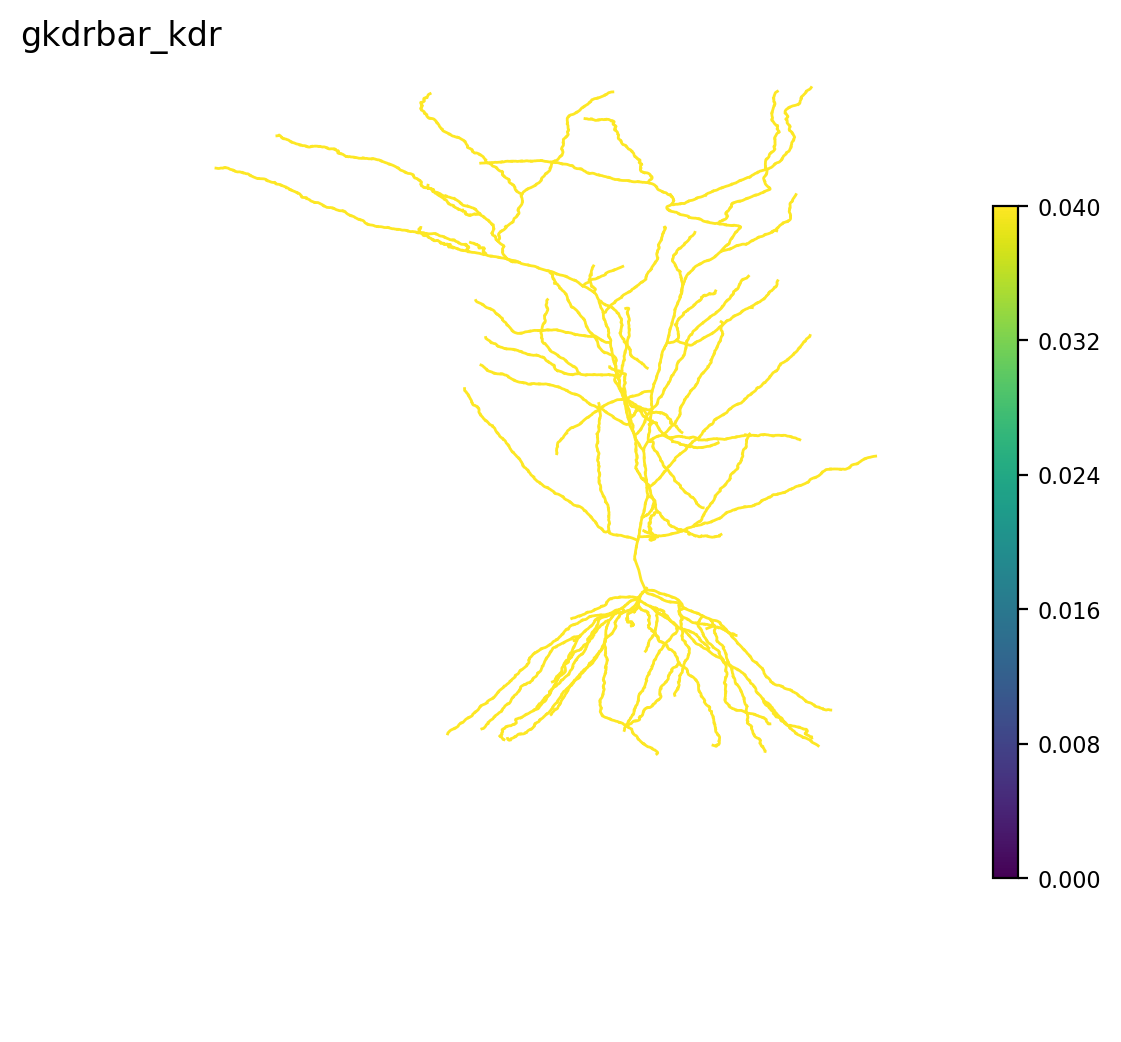

In [21]:
plot_mechanism("gkdrbar_kdr", lw=1.0)

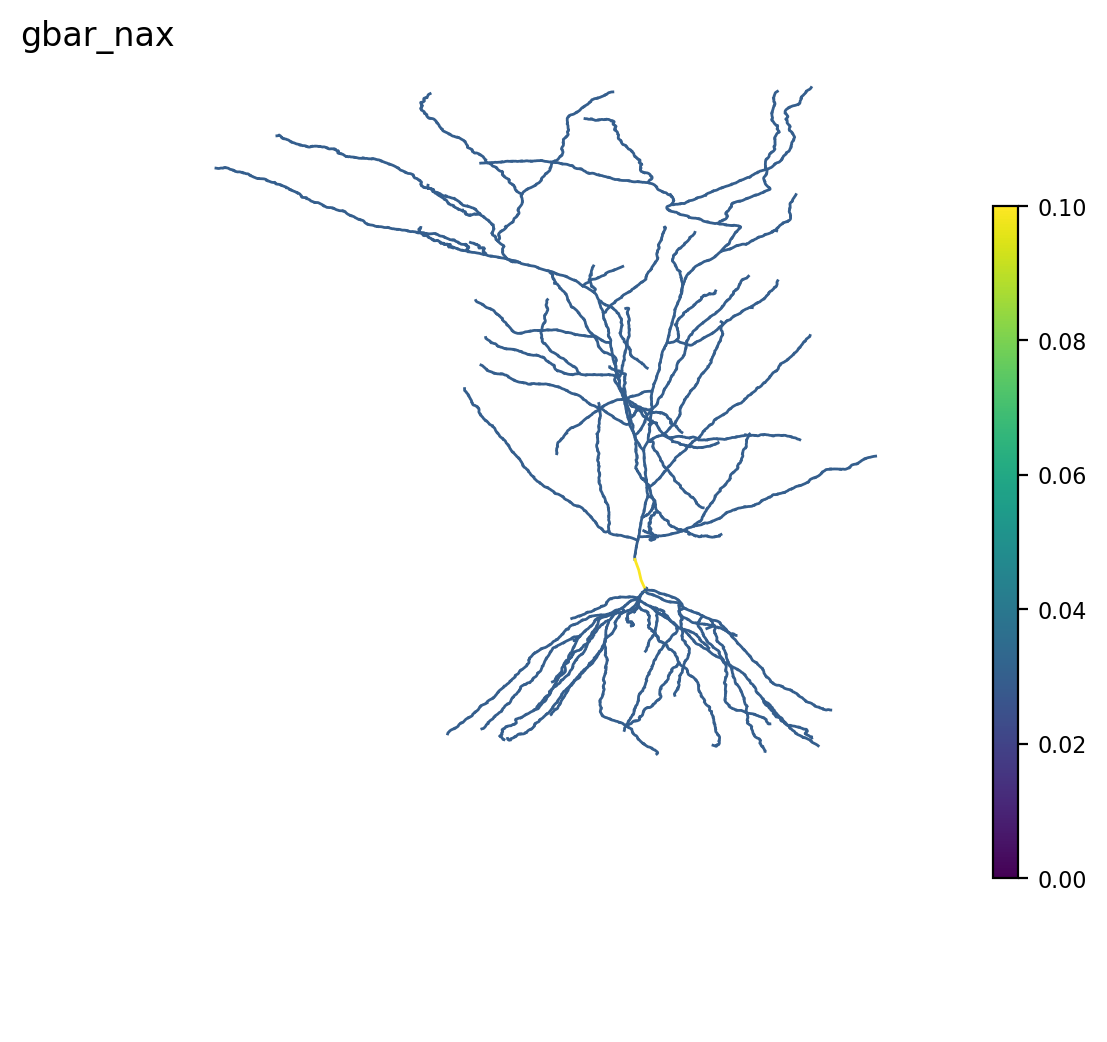

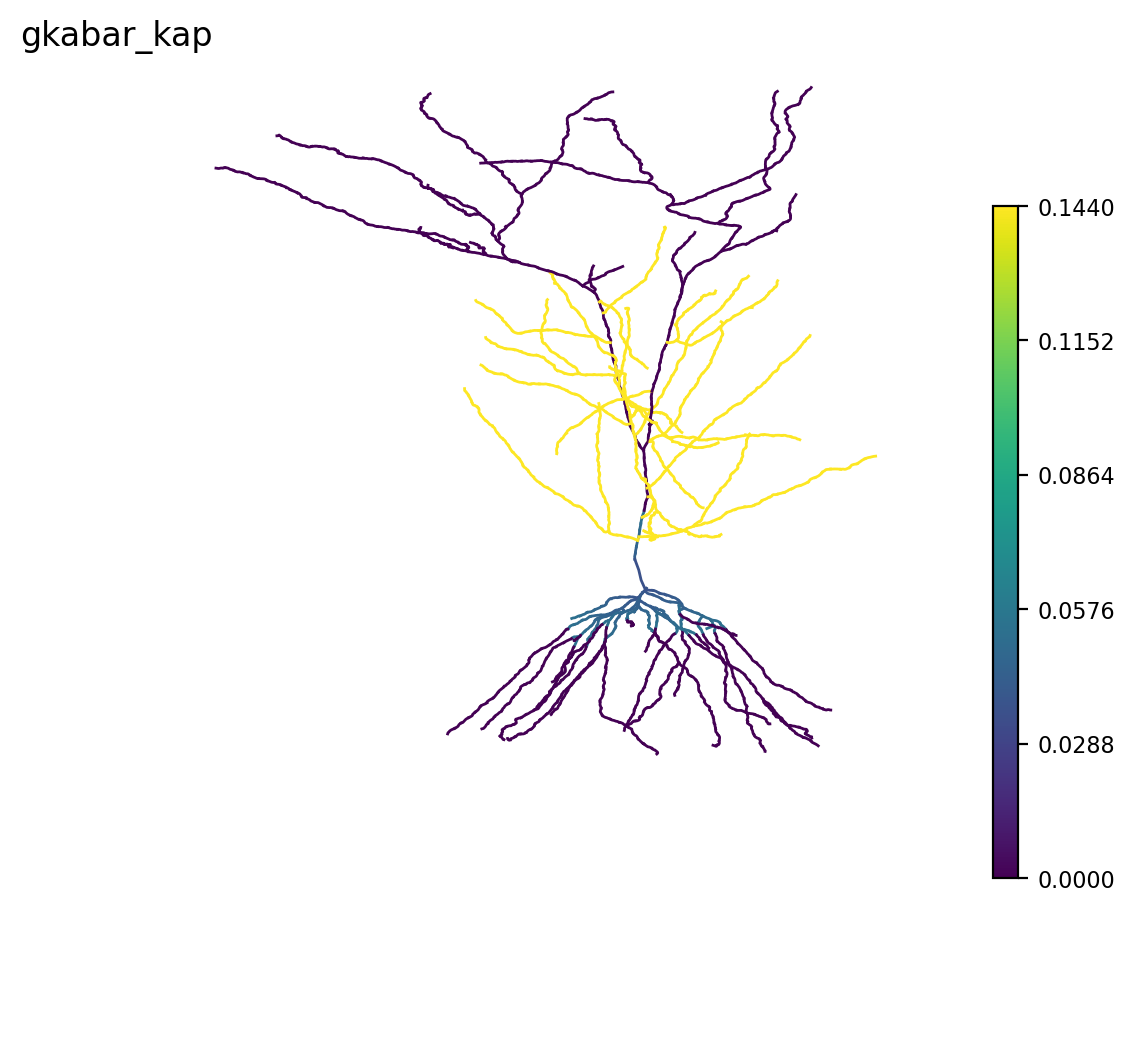

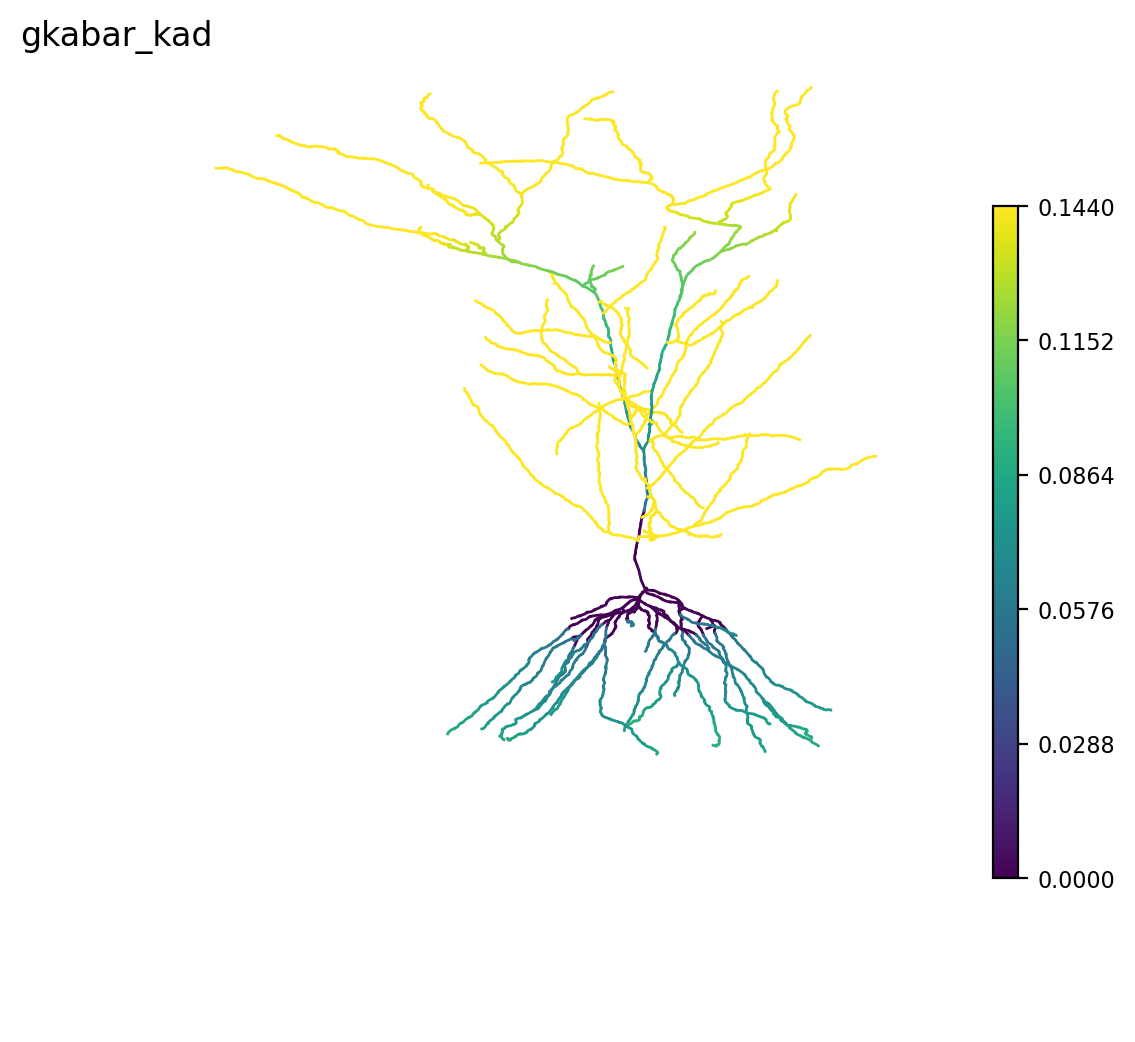

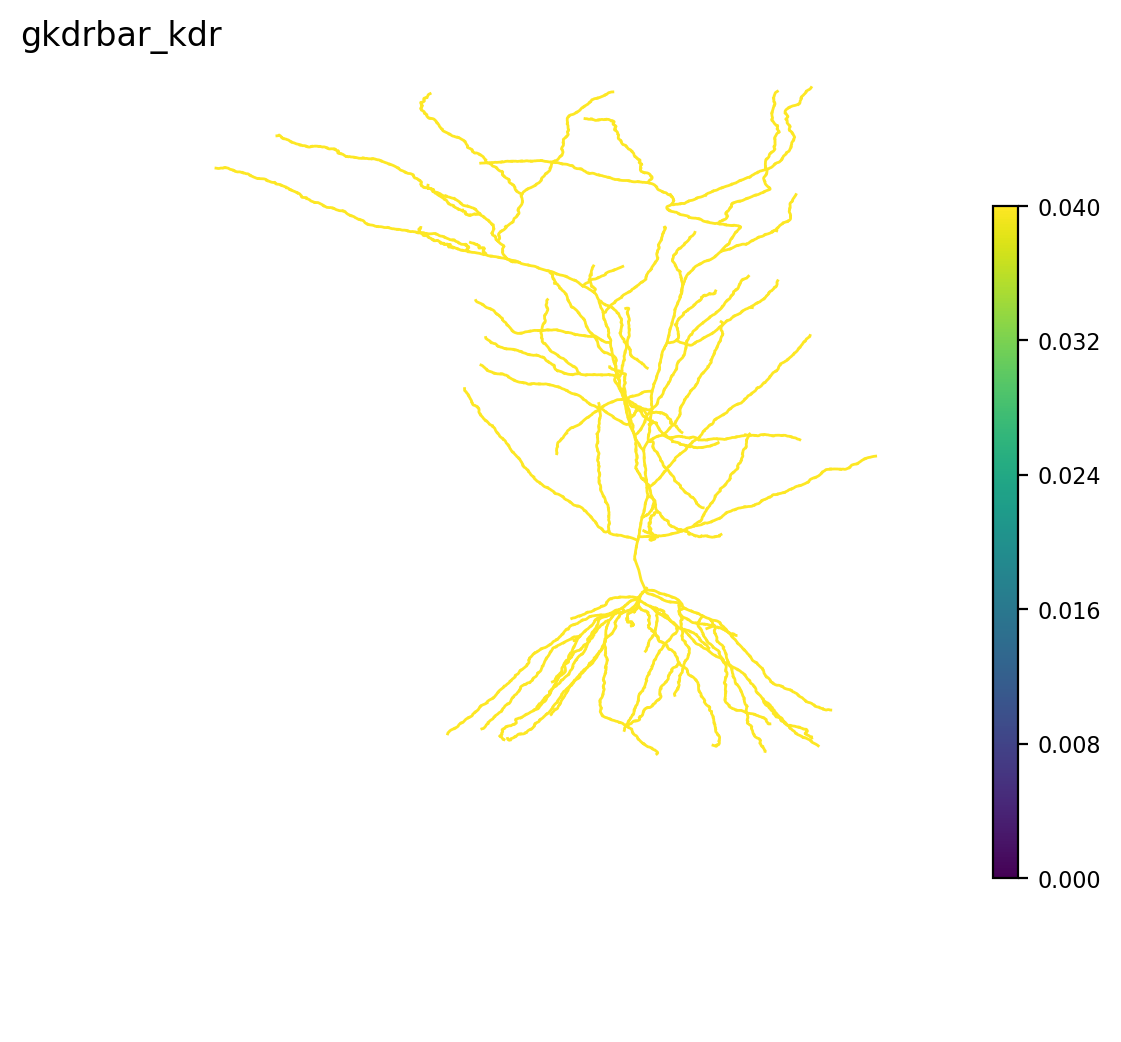

In [22]:
for mech in mech_selected:
    plot_mechanism(mech, lw=1.0)

In [17]:
# h.load_file("iterateSims.hoc")